## Preparation

In [3]:
import torch
from models_arch.Recognizer import *
from utils.randimage import RandomLinesGenerator
import matplotlib.pyplot as plt
import numpy as np

In [4]:
model = RecognizerOneConv()
model.load()

class_mapper: dict = {
    0: '0',
    1: '1',
    2: '2',
    3: '3',
    4: '4',
    5: '5',
    6: '6',
    7: '7',
    8: '8',
    9: '9',
    10: 'blank',
}

## Visualize the kernels

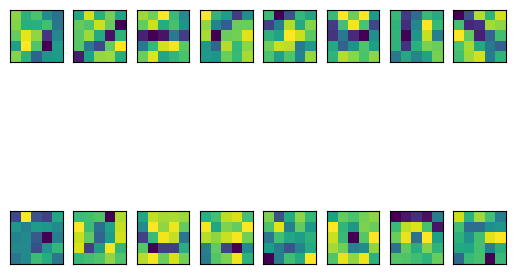

In [33]:
fig, axes = plt.subplots(2, 8, sharex=True, sharey=True, subplot_kw={'xticklabels': '', 'yticklabels': '', 'xticks': (50,), 'yticks': (50,)})
with torch.no_grad():
    for idx, ker in enumerate(model.kernels):


        axes[idx // 8, idx % 8].imshow(ker.squeeze(0))


## Visualize each kernel's predictions

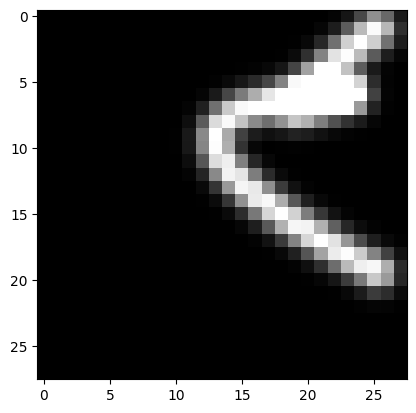

Model prediction:  blank


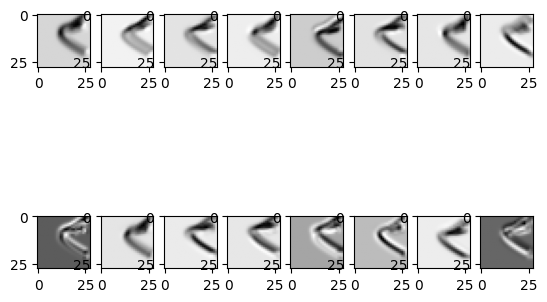

In [38]:
im: torch.Tensor = RandomLinesGenerator().generate()
plt.imshow(im, cmap='gray')
plt.show()
im = im.unsqueeze(0).unsqueeze(0)
fig, axes = plt.subplots(2, 8)

plt.cla()
model.eval()
with torch.no_grad():
    print('Model prediction: ', class_mapper[torch.argmax(torch.softmax(model(im), 1)).item()])
    preds = model[0](im)

    for idx, kernel in enumerate(preds.squeeze(0)):
        axes[idx // 8, idx % 8].imshow(kernel, cmap='gray')
    
plt.show()